## Position of quasras:

You measure the position of a quasar $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

In [1]:
import numpy as np 
from scipy import stats 
import matplotlib.pyplot as plt
import seaborn as sns

### Part 1
- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`) 
- Compare it with the MLE estimator derived above

In [2]:
N = 5 #Number of measurments 
sigma = 0.2
np.random.seed(22)
data = stats.norm(loc = 1, scale = sigma).rvs(N)
data

array([0.98161002, 0.70732987, 1.21635834, 0.95213497, 0.90177417])

In [3]:
x = np.linspace(0.25,1.75,1000)
pdfs = [stats.norm(i, sigma) for i in data]
likelihoods = np.array([pdfs[i].pdf(x) for i in range(N)])

In [4]:
likelihood = np.prod(likelihoods, axis = 0)

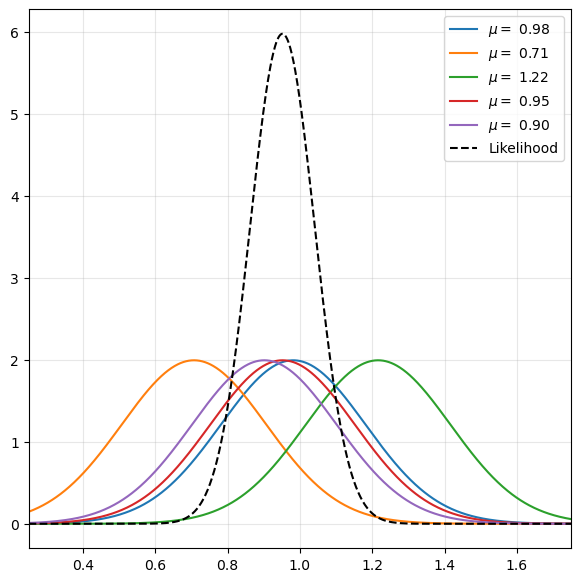

In [7]:
plt.figure(figsize=(7, 7))
for i in range(N):
    plt.plot(x, likelihoods[i], label = fr'$\mu = $ {data[i]:.2f}')

plt.plot(x, likelihood, ls = '--', c='k', label = 'Likelihood')
plt.xlim(0.25, 1.75)
plt.grid(alpha = 0.3)
plt.legend()

In [8]:
#Let's find the max of the likelihood
srt = np.argsort(likelihood)
max_id = srt[-1]
mu_mle = x[max_id]
mu = '\u03bc' #Unicode for mu 
print(f'The likelihood is maximized for {mu} = {mu_mle:.3f}')

The likelihood is maximized for μ = 0.951


In [9]:
#And now let's just compute the mean
M = np.mean(data)
print(f'The the mean of our samples is {mu} = {M:.3f}')

The the mean of our samples is μ = 0.952


The 2 values are practically the same! Great!

## Part 2
Check the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees) 


In [10]:
der = np.diff(np.log(likelihood), n=2)
der /= (x[1]-x[0])**2
der *= -1
sg = '\u03C3' #sigma unicode
sigma_mu = 1/np.sqrt(der[max_id])
print(f'The {sg} for {mu} is: {sigma_mu:.3f}')

The σ for μ is: 0.089


In [11]:
#Let's compute the sigma for a Gaussian case
fisher_sg = sigma/N**0.5
print(f'The erro on {mu} is given by: {fisher_sg:.3f}')

The erro on μ is given by: 0.089


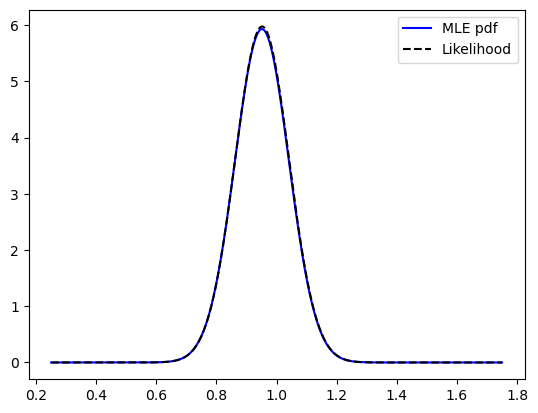

In [12]:
like_lh = stats.norm(loc = mu_mle, scale = sigma_mu)
plt.plot(x, like_lh.pdf(x)*1.33, '-b', label = 'MLE pdf') #Adding a fudge factor as the actual lh is not normalized 
plt.plot(x, likelihood, '--k', label = 'Likelihood')
plt.legend()

### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distribured with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

In [13]:
#Keeping the data from above, let's get their errors
errs = stats.norm(loc = 0.2, scale = 0.05).rvs(N)

In [15]:
prob_pdfs = [stats.norm(i, c) for i, c in zip(data,errs)]
likelihoods = np.array([prob_pdfs[i].pdf(x) for i in range(N)])
likelihood = np.prod(likelihoods, axis = 0)

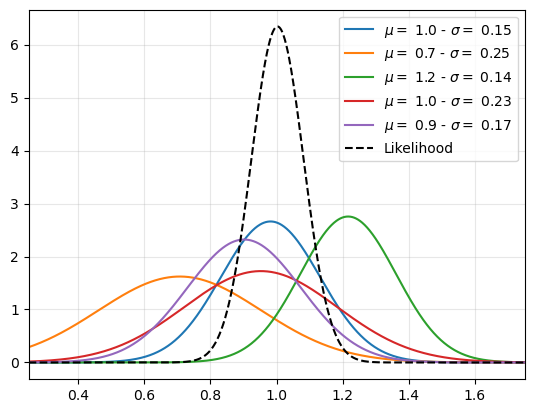

In [18]:
for i in range(N):
    plt.plot(x, likelihoods[i], label = fr'$\mu = $ {data[i]:.1f} - $\sigma = $ {errs[i]:.2f}')

plt.plot(x, likelihood, ls = '--', c='k', label = 'Likelihood')
plt.xlim(0.25, 1.75)
plt.grid(alpha = 0.3)
plt.legend()

In [19]:
srt = np.argsort(likelihood)
max_id = srt[-1]
mu_mle = x[max_id]
mu = '\u03bc' #Unicode for mu 
print(f'The likelihood is maximized for {mu} = {mu_mle:.3f}')
M = np.average(data, weights = 1/errs**2)
print(f'The estimator in this case is the mean: {mu} = {M:.3f}')

The likelihood is maximized for μ = 1.002
The estimator in this case is the mean: μ = 1.003


In [21]:
der = np.diff(np.log(likelihood), n=2)
der /= (x[1]-x[0])**2
der *= -1
sg = '\u03C3' #sigma unicode
sigma_mu = 1/np.sqrt(der[max_id])
print(f'The {sg} is {sigma_mu:.3f}')

#Let's compute the sigma given by fisher
fisher_sg = (np.sqrt(np.sum(1/(errs**2))))**-1
print(f'The error is given by {fisher_sg:.3f}')

The σ is 0.079
The error is given by 0.079


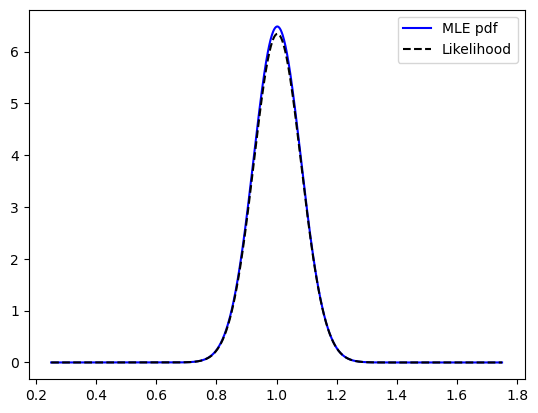

In [25]:
like_lh = stats.norm(loc = mu_mle, scale = sigma_mu)
plt.plot(x, like_lh.pdf(x)*1.28, '-b', label = 'MLE pdf')
plt.plot(x, likelihood, '--k', label = 'Likelihood')
plt.legend()